In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy

In [55]:
df=pd.read_excel("C:\\Users\\Nimish\\Downloads\\srg-tes-epilepsy-models-main\\srg-tes-epilepsy-models-main\\analysis\\test_2.xlsx",header=None)

In [56]:
df.head(5)

,0,1,2,3,4,5,6,7
0,1,49.335624,2,0.090361,0.456545,174.769259,36.052235,1
1,2,43.218742,1,0.091101,0.531560,0.000000,0.000000,1
2,3,89.691352,1,0.049136,0.516980,0.000000,0.000000,1
3,4,96.443434,1,0.036400,0.441594,0.000000,0.000000,1
4,5,120.371216,2,0.085344,0.509407,354.072996,70.515245,1


In [5]:
df.info(verbose=False)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Columns: 8 entries, itr to status
dtypes: float64(5), int64(3)
memory usage: 13.6 KB


In [6]:
df.shape

(215, 8)

In [7]:
df.describe()

,itr,tr_time,tr_num,low_lev,high_lev,state_tim,tr2_tim,status
count,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000
mean,109.000000,35.261507,0.827907,0.064505,0.325318,15.745026,5.805134,0.567442
std,62.209324,49.007390,1.193112,0.018607,0.166348,68.607986,17.824087,0.496587
min,2.000000,0.000000,0.000000,0.021897,0.074387,0.000000,0.000000,0.000000
25%,55.500000,0.000000,0.000000,0.052853,0.148441,0.000000,0.000000,0.000000
50%,109.000000,26.714513,1.000000,0.062715,0.359331,0.000000,0.000000,1.000000
75%,162.500000,47.536728,1.000000,0.073313,0.486316,0.000000,0.000000,1.000000
max,216.000000,294.246889,12.000000,0.186829,0.572743,664.484096,95.335897,1.000000


In [8]:
df.info(verbose=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Columns: 8 entries, itr to status
dtypes: float64(5), int64(3)
memory usage: 13.6 KB


In [9]:
df.columns

Index(['itr', 'tr_time', 'tr_num', 'low_lev', 'high_lev', 'state_tim',
       'tr2_tim', 'status'],
      dtype='object')

In [10]:
df.index

RangeIndex(start=0, stop=215, step=1)

In [11]:
df.columns.to_list()

['itr',
 'tr_time',
 'tr_num',
 'low_lev',
 'high_lev',
 'state_tim',
 'tr2_tim',
 'status']

In [12]:
state_time = df.state_tim

axis=0 for rows and axis =1 for columns

In [13]:
trans_time = df[['tr_time','tr2_tim']]

Selecting only transitions

In [14]:
trans_df = df[(df['status']==1)]

In [15]:
trans_df

,itr,tr_time,tr_num,low_lev,high_lev,state_tim,tr2_tim,status
6,8,37.528521,2,0.099173,0.447506,179.816650,24.690806,1
7,9,24.075341,4,0.021897,0.306133,11.508777,48.422507,1
10,12,8.260958,2,0.053165,0.369371,77.430215,8.776309,1
15,17,29.232822,3,0.052745,0.452663,95.179764,81.928711,1
17,19,28.023745,1,0.057136,0.539175,0.000000,0.000000,1
...,...,...,...,...,...,...,...,...
204,206,57.548048,1,0.052657,0.514642,0.000000,0.000000,1
207,209,23.050710,2,0.068020,0.444641,316.231307,30.287873,1
209,211,42.696966,1,0.073273,0.554039,0.000000,0.000000,1
210,212,68.990985,1,0.054578,0.520765,0.000000,0.000000,1


In [16]:
trans_df_1 =trans_df[(trans_df['tr_num']==1)]

In [17]:
trans_df_1

,itr,tr_time,tr_num,low_lev,high_lev,state_tim,tr2_tim,status
17,19,28.023745,1,0.057136,0.539175,0.0,0.0,1
18,20,73.436117,1,0.063478,0.539513,0.0,0.0,1
21,23,74.540401,1,0.043263,0.481097,0.0,0.0,1
26,28,201.258776,1,0.050134,0.515588,0.0,0.0,1
28,30,43.473451,1,0.058005,0.444199,0.0,0.0,1
...,...,...,...,...,...,...,...,...
198,200,31.548208,1,0.065521,0.532905,0.0,0.0,1
203,205,198.761518,1,0.081728,0.469804,0.0,0.0,1
204,206,57.548048,1,0.052657,0.514642,0.0,0.0,1
209,211,42.696966,1,0.073273,0.554039,0.0,0.0,1


In [18]:
trans_df_1.describe()

,itr,tr_time,tr_num,low_lev,high_lev,state_tim,tr2_tim,status
count,95.000000,95.000000,95.0,95.000000,95.000000,95.0,95.0,95.0
mean,114.389474,66.531551,1.0,0.061268,0.475605,0.0,0.0,1.0
std,56.648843,52.520837,0.0,0.013909,0.058528,0.0,0.0,0.0
min,19.000000,21.654822,1.0,0.033660,0.301577,0.0,0.0,1.0
25%,63.500000,35.858960,1.0,0.051102,0.440625,0.0,0.0,1.0
50%,118.000000,45.772843,1.0,0.060387,0.490270,0.0,0.0,1.0
75%,163.500000,68.480606,1.0,0.068722,0.517576,0.0,0.0,1.0
max,212.000000,294.246889,1.0,0.106454,0.572743,0.0,0.0,1.0


In [19]:
trans_df_2 = trans_df[(trans_df['tr_num']==2)]

In [20]:
trans_df_2

,itr,tr_time,tr_num,low_lev,high_lev,state_tim,tr2_tim,status
6,8,37.528521,2,0.099173,0.447506,179.816650,24.690806,1
10,12,8.260958,2,0.053165,0.369371,77.430215,8.776309,1
23,25,31.729944,2,0.080304,0.504650,365.309393,75.265864,1
31,33,46.345383,2,0.064585,0.450818,36.082535,40.887669,1
39,41,23.143138,2,0.076982,0.384244,51.393183,21.387466,1
54,56,24.440518,2,0.069485,0.377055,35.866030,61.225996,1
71,73,103.251356,2,0.081917,0.459145,134.981836,30.955900,1
94,96,122.029256,2,0.045343,0.502513,229.617905,29.977909,1
108,110,28.785011,2,0.089009,0.539331,239.080586,46.549071,1
117,119,119.291392,2,0.055564,0.307956,664.484096,84.165624,1


In [21]:
trans_df_3 = trans_df[(trans_df['tr_num']==3)]

In [22]:
trans_df_3

,itr,tr_time,tr_num,low_lev,high_lev,state_tim,tr2_tim,status
15,17,29.232822,3,0.052745,0.452663,95.179764,81.928711,1
24,26,61.740699,3,0.038272,0.307356,36.937462,60.080154,1
44,46,13.250881,3,0.039334,0.344722,15.261904,19.100635,1
49,51,13.250881,3,0.039334,0.344722,15.261904,19.100635,1
118,120,17.177773,3,0.103696,0.355597,38.899478,76.570986,1
121,123,19.522487,3,0.066982,0.356508,32.050922,74.992637,1
129,131,27.431176,3,0.095711,0.356476,39.710962,17.357428,1
156,158,92.925073,3,0.041145,0.393526,20.770429,71.294680,1


# Loading csv file with only 1 transition iteration data


In [3]:
df=pd.read_csv(r'C:\Users\Nimish\Downloads\srg-tes-epilepsy-models-main\srg-tes-epilepsy-models-main\analysis\tr1_4.csv',header = None)

In [4]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,73,74,75,76,77,78,79,80,81,82
0,0.030372,0.054294,0.005140,0.017968,0.047439,0.034575,0.069411,0.043609,0.013525,0.020673,...,0.037005,0.069977,0.011925,0.024968,0.018936,0.063426,0.046795,0.036642,0.027823,0.050052
1,0.032303,0.055056,0.003924,0.018189,0.046298,0.033553,0.068482,0.043120,0.011936,0.021279,...,0.036067,0.071549,0.010849,0.025254,0.018469,0.064092,0.046630,0.035426,0.026607,0.049578
2,0.034259,0.055756,0.003012,0.018456,0.045139,0.032490,0.067550,0.042618,0.010370,0.021873,...,0.035130,0.073039,0.009825,0.025531,0.018038,0.064684,0.046394,0.034500,0.025401,0.049067
3,0.036231,0.056393,0.002819,0.018770,0.043968,0.031389,0.066617,0.042102,0.008830,0.022454,...,0.034195,0.074443,0.008860,0.025796,0.017644,0.065203,0.046085,0.033879,0.024206,0.048519
4,0.038212,0.056967,0.003537,0.019131,0.042791,0.030251,0.065687,0.041575,0.007322,0.023023,...,0.033264,0.075759,0.007960,0.026050,0.017289,0.065648,0.045706,0.033571,0.023024,0.047933


In [13]:
df.drop(0,axis=1,inplace=True)
df.head()



,1,2,3,4,5,6,7,8,9,10,...,206,207,208,209,210,211,212,213,214,215
0,1.000000,2.000000,3.000000,4.000000,5.000000,6.000000,7.000000,8.000000,9.000000,10.000000,...,206.000000,207.000000,208.000000,209.000000,210.000000,211.000000,212.000000,213.000000,214.000000,215.000000
1,0.022768,0.055749,0.025382,0.019552,0.050242,0.043795,0.091328,0.026842,0.059868,0.048849,...,0.032327,0.019123,0.049971,0.048504,0.027823,0.050052,0.032468,0.020933,0.024171,0.052354
2,0.021793,0.055176,0.024925,0.020399,0.050846,0.045265,0.089168,0.026258,0.060842,0.049139,...,0.033586,0.016471,0.050032,0.048413,0.026607,0.049578,0.031886,0.022371,0.024645,0.051979
3,0.021040,0.054567,0.024459,0.021216,0.051489,0.046709,0.086964,0.025692,0.061756,0.049449,...,0.034866,0.013860,0.050022,0.048279,0.025401,0.049067,0.031317,0.023833,0.025148,0.051611
4,0.020524,0.053923,0.023986,0.022002,0.052166,0.048127,0.084719,0.025148,0.062608,0.049774,...,0.036161,0.011312,0.049941,0.048103,0.024206,0.048519,0.030765,0.025310,0.025678,0.051252


In [14]:
df.drop(0,inplace=True)
df.head()

,1,2,3,4,5,6,7,8,9,10,...,206,207,208,209,210,211,212,213,214,215
1,0.022768,0.055749,0.025382,0.019552,0.050242,0.043795,0.091328,0.026842,0.059868,0.048849,...,0.032327,0.019123,0.049971,0.048504,0.027823,0.050052,0.032468,0.020933,0.024171,0.052354
2,0.021793,0.055176,0.024925,0.020399,0.050846,0.045265,0.089168,0.026258,0.060842,0.049139,...,0.033586,0.016471,0.050032,0.048413,0.026607,0.049578,0.031886,0.022371,0.024645,0.051979
3,0.021040,0.054567,0.024459,0.021216,0.051489,0.046709,0.086964,0.025692,0.061756,0.049449,...,0.034866,0.013860,0.050022,0.048279,0.025401,0.049067,0.031317,0.023833,0.025148,0.051611
4,0.020524,0.053923,0.023986,0.022002,0.052166,0.048127,0.084719,0.025148,0.062608,0.049774,...,0.036161,0.011312,0.049941,0.048103,0.024206,0.048519,0.030765,0.025310,0.025678,0.051252
5,0.020250,0.053247,0.023505,0.022757,0.052875,0.049517,0.082437,0.024627,0.063396,0.050114,...,0.037468,0.008873,0.049789,0.047887,0.023024,0.047933,0.030231,0.026793,0.026228,0.050905


In [5]:
df.shape

(40000, 83)

In [6]:
df.columns

Int64Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
            17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
            34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
            51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
            68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82],
           dtype='int64')

#### Creating timesteps

In [7]:
time_steps = list(range(0,40000))   #timesteps upto nepochs
time=np.multiply(time_steps,0.05)

## Smoothing data

#### Smooth Dataframe

In [8]:
df_smooth = df.rolling(window=800, center=True).mean()

#### Comparing smooth and original


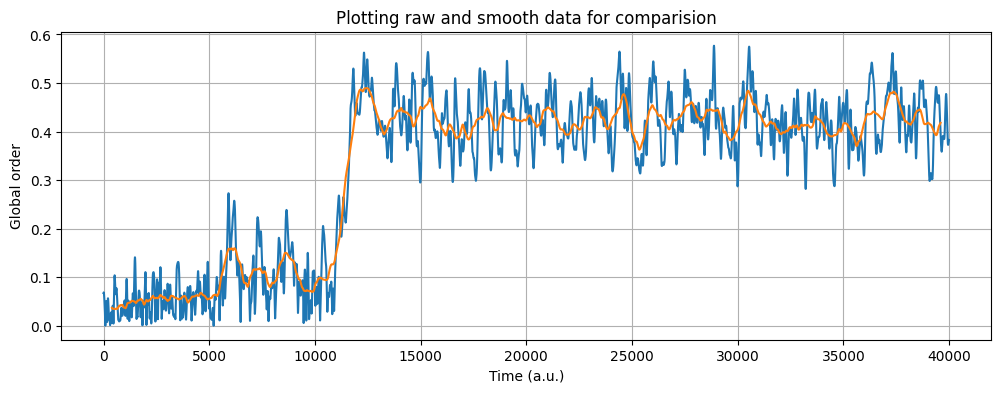

In [9]:
f = plt.figure(figsize=(12, 4))
plt.title("Plotting raw and smooth data for comparision") 
n=11
sync_order = df[n]
sync_smooth = df_smooth[n]
plt.plot(time_steps,sync_order)
plt.plot(time_steps,sync_smooth)
plt.ylabel("Global order")
plt.xlabel("Time (a.u.)")
plt.grid(True)
plt.show()



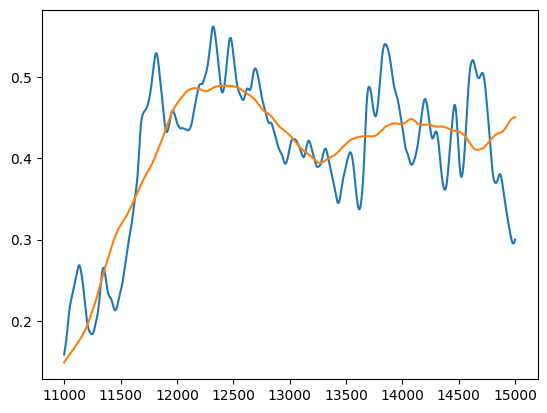

In [10]:
plt.plot(time_steps[11000:15000],sync_order[11000:15000])
plt.plot(time_steps[11000:15000],sync_smooth[11000:15000])

#Plot with time units
#plt.plot(np.multiply(time_steps[25000:30000],0.05),sync_order[25000:30000])
#plt.plot(np.multiply(time_steps[25000:30000],0.05),sync_smooth[25000:30000])

#### Drop Nan 

In [11]:
df_na=df_smooth.dropna()

In [12]:
df_na.shape

(39201, 83)

#### Defining timesteps and time for dataframe with removed NaN

In [13]:
time_steps_na = list(range(0,39201))   #timesteps upto nepochs
time_na=np.multiply(time_steps_na,0.05)

In [23]:
len(time_na)

39201

#### Checking how one can shift

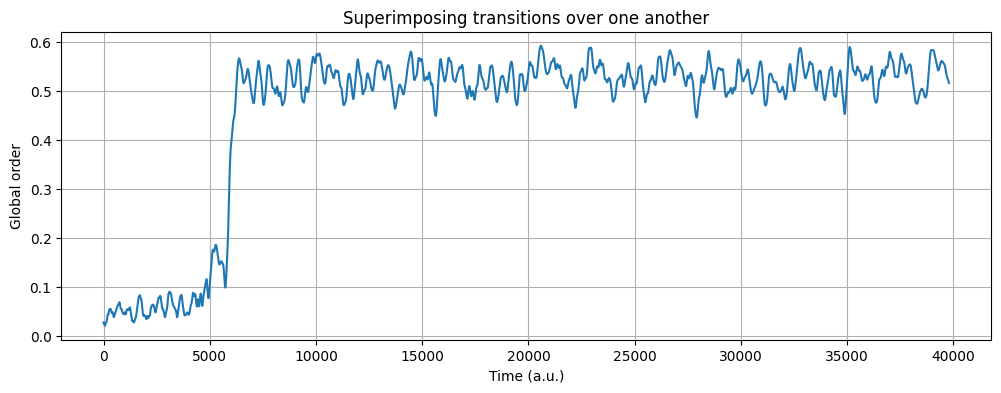

In [27]:
f = plt.figure(figsize=(12, 4))
plt.title("Superimposing transitions over one another") 
plt.plot(time_steps_na,df_na[2])
#plt.plot(time_steps_na,df_na[1])
#plt.plot(time_steps_na,df_na[0].shift(-21000))
plt.grid()
plt.ylabel("Global order")
plt.xlabel("Time (a.u.)")
plt.show()

#### Shifting all transition to 15000 timestep

In [49]:
df_na.shape

(39201, 83)

In [50]:
df_na.head()

,0,1,2,3,4,5,6,7,8,9,...,73,74,75,76,77,78,79,80,81,82
400,0.053564,0.043020,0.039418,0.045233,0.049413,0.045047,0.059516,0.034209,0.048778,0.037716,...,0.035588,0.045041,0.046383,0.047433,0.046327,0.051212,0.047406,0.044163,0.051054,0.039953
401,0.053565,0.043056,0.039456,0.045241,0.049419,0.045044,0.059478,0.034179,0.048871,0.037850,...,0.035604,0.044983,0.046403,0.047469,0.046411,0.051215,0.047372,0.044170,0.051046,0.039936
402,0.053566,0.043090,0.039498,0.045249,0.049428,0.045043,0.059440,0.034149,0.048966,0.037985,...,0.035621,0.044923,0.046426,0.047504,0.046496,0.051220,0.047336,0.044181,0.051037,0.039919
403,0.053568,0.043123,0.039541,0.045256,0.049440,0.045044,0.059400,0.034121,0.049062,0.038121,...,0.035639,0.044861,0.046450,0.047538,0.046581,0.051226,0.047299,0.044195,0.051029,0.039903
404,0.053569,0.043153,0.039586,0.045262,0.049455,0.045046,0.059360,0.034094,0.049159,0.038257,...,0.035659,0.044797,0.046478,0.047570,0.046666,0.051233,0.047260,0.044212,0.051020,0.039888


In [98]:
df_check = df_na.apply(lambda c: c>0.3)

In [99]:
df_check.dtypes

0     bool
1     bool
2     bool
3     bool
4     bool
      ... 
78    bool
79    bool
80    bool
81    bool
82    bool
Length: 83, dtype: object

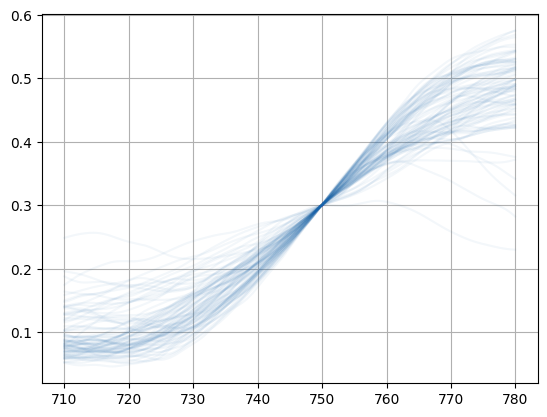

In [100]:
import matplotlib.cm as cm
set_point = 15000
c=0
for i in range(0,83):
    for val in df_check[i]:
        c+=1
        if val == True:
            ts=c
            c=0
            break
    
    if ts>15000:
        
        plt.plot(time_na[14200:15600],df_na[i].shift(-(ts-set_point))[14200:15600],color=cm.Blues(0.8, 0.05), lw=1.5)
        plt.grid()
    else:
        
        plt.plot(time_na[14200:15600],df_na[i].shift(set_point-ts)[14200:15600],color=cm.Blues(0.8, 0.05), lw=1.5)
        plt.grid()
    i+=1


### Plotting full time

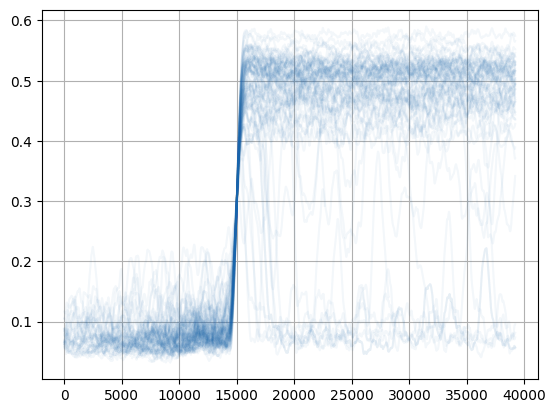

In [101]:
import matplotlib.cm as cm
set_point = 15000
c=0
for i in range(0,83):
    for val in df_check[i]:
        c+=1
        if val == True:
            ts=c
            c=0
            break
    
    if ts>15000:
        
        plt.plot(time_steps_na,df_na[i].shift(-(ts-set_point)),color=cm.Blues(0.8, 0.05), lw=1.5)
        plt.grid()
    else:
        
        plt.plot(time_steps_na,df_na[i].shift(set_point-ts),color=cm.Blues(0.8, 0.05), lw=1.5)
        plt.grid()
    i+=1


# Finding Transition time

Using df_na with NaN values removed

38.800000000000004
34980
35756


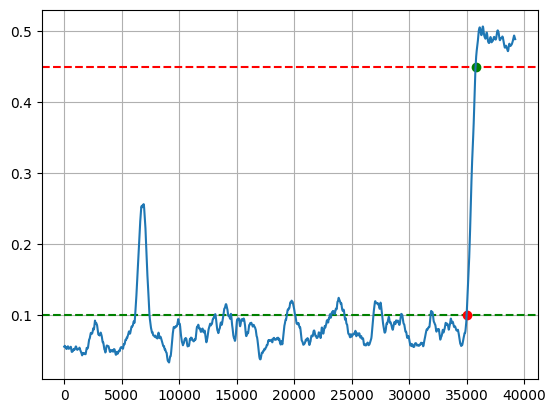

In [18]:
n=64
data = np.array(df_na[n])
upper_crossing=np.where(data >= 0.45)[0][0]
l1 = np.where(data >= 0.1)[0]
l2=np.where(data <= 0.101)[0]
low_intersection = np.intersect1d(l1, l2)
lower_crossing=low_intersection[-1]
t=(upper_crossing-lower_crossing)*0.05
print(t)
print(lower_crossing)
print(upper_crossing)
fig, ax = plt.subplots()

# Plot 
ax.axhline(y=data[upper_crossing], color='r', linestyle='--', label='y = upper level')
ax.axhline(y=data[lower_crossing], color='g', linestyle='--', label='y = lower level')
plt.plot( lower_crossing, data[lower_crossing], "ro")
plt.plot(upper_crossing,data[upper_crossing],"go")
#plt.text(lower_crossing - 0.08,data[lower_crossing] , "Lower threshold")
#plt.text(upper_crossing - 0.08,data[upper_crossing] , "Upper threshold")
plt.plot(time_steps_na,data)



plt.grid()
    

In [19]:
trans_time=[]
data_trans=df_na[0]        #initialising dataframe for storing only transition iterations
data_no_trans=df_na[0]     #initialising dataframe for storing only no transition iterations
for i in range(0,83):    

    
    data = np.array(df_na[i])
    indice=np.where(data >= 0.45)[0]
    
    if indice.size > 0:
        upper_crossing = indice[0]
        data_trans=pd.concat([data_trans, df_na[i]], axis=1)
        

    else:
        #data_no_trans=pd.concat([data_no_trans, df_na[i]], axis=1)
        continue
    
    l1 = np.where(data >= 0.1)[0]
    l2=np.where(data <= 0.101)[0]
    low_intersection = np.intersect1d(l1, l2)
    low_upd =low_intersection[low_intersection<upper_crossing]

    lower_crossing=low_upd[-1]
    
    t=(upper_crossing-lower_crossing)*0.05
    trans_time.append(t)
    

print(np.array(trans_time))

[ 29.3   69.1   84.35 189.35  48.5   35.15  34.8   51.4   55.95  32.8
  38.15  65.4  155.1   36.8   97.1  118.75  36.85  36.3   70.2   48.15
  92.65  32.45  49.85  54.7   76.8   37.25  60.65  51.75  58.05  44.65
 116.4  103.7   65.9   75.5   34.7   46.65  60.45  33.95  62.7   31.5
  34.75  37.25  33.55  34.1   34.55  38.55  38.2   43.35  50.2   34.45
  56.3   54.05 118.35  86.8  150.25 116.    38.8   48.2   61.95  39.7
  67.75  43.75  31.2   32.45  60.55  38.75  58.8  225.8   59.95  53.7
  32.05 146.5   49.3   38.3   68.85]


In [20]:
data_trans.head()

,0,0,1,2,3,4,5,6,7,8,...,73,74,75,76,77,78,79,80,81,82
400,0.053564,0.053564,0.043020,0.039418,0.045233,0.049413,0.045047,0.059516,0.034209,0.048778,...,0.035588,0.045041,0.046383,0.047433,0.046327,0.051212,0.047406,0.044163,0.051054,0.039953
401,0.053565,0.053565,0.043056,0.039456,0.045241,0.049419,0.045044,0.059478,0.034179,0.048871,...,0.035604,0.044983,0.046403,0.047469,0.046411,0.051215,0.047372,0.044170,0.051046,0.039936
402,0.053566,0.053566,0.043090,0.039498,0.045249,0.049428,0.045043,0.059440,0.034149,0.048966,...,0.035621,0.044923,0.046426,0.047504,0.046496,0.051220,0.047336,0.044181,0.051037,0.039919
403,0.053568,0.053568,0.043123,0.039541,0.045256,0.049440,0.045044,0.059400,0.034121,0.049062,...,0.035639,0.044861,0.046450,0.047538,0.046581,0.051226,0.047299,0.044195,0.051029,0.039903
404,0.053569,0.053569,0.043153,0.039586,0.045262,0.049455,0.045046,0.059360,0.034094,0.049159,...,0.035659,0.044797,0.046478,0.047570,0.046666,0.051233,0.047260,0.044212,0.051020,0.039888


In [21]:
data_trans.columns

Int64Index([ 0,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 14, 15, 16, 17,
            18, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
            36, 37, 38, 39, 42, 43, 44, 45, 46, 47, 48, 49, 51, 52, 53, 54, 55,
            56, 58, 59, 60, 61, 62, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74,
            75, 76, 77, 78, 79, 80, 81, 82],
           dtype='int64')

189.35000000000002
6146
9933


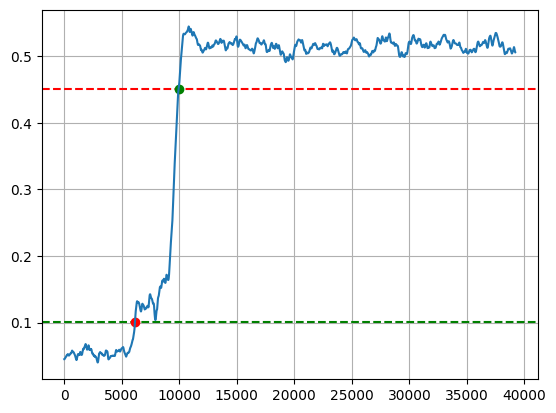

In [28]:
n=3
data = np.array(data_trans[n])
upper_crossing=np.where(data >= 0.45)[0][0]
l1 = np.where(data >= 0.1)[0]
l2=np.where(data <= 0.101)[0]
low_intersection = np.intersect1d(l1, l2)

#putting conditions for iterations having falling transition
low_upd =low_intersection[low_intersection<upper_crossing]
lower_crossing=low_upd[-1]
t=(upper_crossing-lower_crossing)*0.05
print(t)
print(lower_crossing)
print(upper_crossing)
fig, ax = plt.subplots()

# Plot 
ax.axhline(y=data[upper_crossing], color='r', linestyle='--', label='y = upper level')
ax.axhline(y=data[lower_crossing], color='g', linestyle='--', label='y = lower level')
plt.plot( lower_crossing, data[lower_crossing], "ro")
plt.plot(upper_crossing,data[upper_crossing],"go")
#plt.text(lower_crossing - 0.08,data[lower_crossing] , "Lower threshold")
#plt.text(upper_crossing - 0.08,data[upper_crossing] , "Upper threshold")
plt.plot(time_steps_na,data)



plt.grid()

In [46]:
data_trans.drop(0,axis=1,inplace=True)

(array([27.,  8., 11., 10.,  5.,  2.,  2.,  1.,  2.,  2.,  0.,  1.,  2.,
         0.,  0.,  0.,  1.,  0.,  0.,  1.]),
 array([ 29.3  ,  39.125,  48.95 ,  58.775,  68.6  ,  78.425,  88.25 ,
         98.075, 107.9  , 117.725, 127.55 , 137.375, 147.2  , 157.025,
        166.85 , 176.675, 186.5  , 196.325, 206.15 , 215.975, 225.8  ]),
 <BarContainer object of 20 artists>)

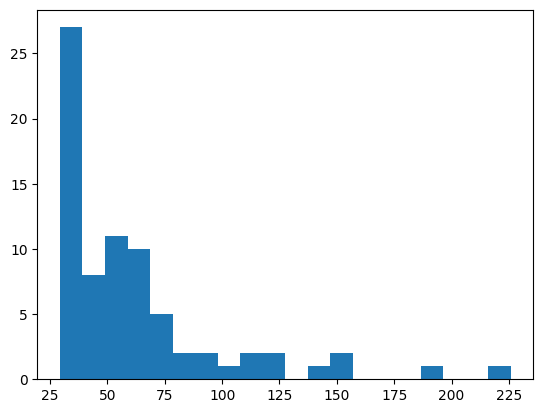

In [23]:
plt.hist(trans_time,bins=20
         )

#### Finding time in synchronised state for transitions which falls back

In [202]:
fwd_data=np.array(data[upper_crossing:])
fwd_data.size


25811

In [213]:
check

array([25255, 25256, 25257, 25258, 25259, 25260, 25261, 25262, 25263,
       25264, 25265, 25266, 25267, 25268, 25269, 25270, 25271, 25272,
       25273, 25274, 25275, 25276, 25277, 25278, 25279, 25280, 25281,
       25282, 25283, 25284, 25285, 25286, 25287, 25288, 25289, 25290,
       25291, 25292, 25293, 25294, 25295, 25296, 25297, 25298, 25299,
       25300, 25301, 25302, 25303, 25304, 25305, 25306, 25307, 25308,
       25309, 25310, 25311, 25312, 25313, 25314, 25315, 25316, 25317,
       25318, 25319, 25320, 25321, 25322, 25323, 25324, 25325, 25326,
       25327, 25328, 25329, 25330, 25331, 25332, 25333, 25334, 25335,
       25336, 25337, 25338, 25339, 25340, 25341, 25342, 25343, 25344,
       25345, 25346, 25347, 25348, 25349, 25350, 25351, 25352, 25353,
       25354, 25355, 25356, 25357, 25358, 25359, 25360, 25361, 25362,
       25363, 25364, 25365, 25366, 25367, 25368, 25369, 25370, 25371,
       25372, 25373, 25374, 25375, 25376, 25377, 25378, 25379, 25380,
       25381, 25382,

In [24]:
lower_crs_up=0

#### Measuring time in synchronized state

1317.5500000000002


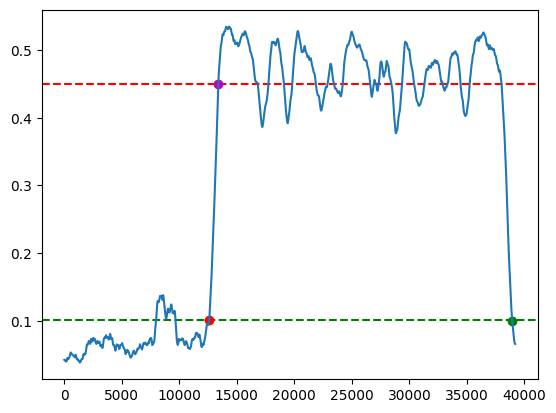

In [27]:
n=67 #put n as what iteration you want to plot,use 2,4,67
state_time=[]
data = np.array(df_na[n])
upper_crossing=np.where(data >= 0.45)[0][0]
l1 = np.where(data >= 0.1)[0]
l2=np.where(data <= 0.101)[0]
low_intersection = np.intersect1d(l1, l2)


#putting conditions to check for 1 transition only
low_upd =low_intersection[low_intersection<upper_crossing]
lower_crossing=low_upd[-1]

#checking for another transition
fwd_data=np.array(data[upper_crossing:])


#upper_crs=np.where(fwd_data >= 0.45)[0][-1]
check=np.where(fwd_data <= 0.2)[0]

if check.size > 0:
    ind=np.where(fwd_data <= 0.1)[0]
    lower_crs = ind[0]
    lower_crs_up = lower_crs+upper_crossing
    st_time=lower_crs_up-lower_crossing
    state_time.append(st_time)

else:
    #data_no_trans=pd.concat([data_no_trans, df_na[i]], axis=1)
    
    pass

fig, ax = plt.subplots()

# Plot 
ax.axhline(y=data[upper_crossing], color='r', linestyle='--', label='y = upper level')
ax.axhline(y=data[lower_crossing], color='g', linestyle='--', label='y = lower level')
plt.plot( lower_crossing, data[lower_crossing], "ro")
plt.plot(upper_crossing,data[upper_crossing],"mo")
plt.plot( lower_crs_up, data[lower_crs_up], "go")
#plt.plot(upper_crs,data[upper_crs],"co")
#plt.text(lower_crossing - 0.08,data[lower_crossing] , "Lower threshold")
#plt.text(upper_crossing - 0.08,data[upper_crossing] , "Upper threshold")
plt.plot(time_steps_na,data)

print(st_time*0.05)

lower_crs_up=0
st_time=0


## Automating

Find iterations which have transition

Find transition times and store in trans_time

Find stay time in synchronised state and store in state_time



In [28]:
#Reading datafile containing iteration data
df=pd.read_csv(r"C:\Users\Nimish\Downloads\srg-tes-epilepsy-models-main\srg-tes-epilepsy-models-main\analysis\data.csv")

In [29]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,206,207,208,209,210,211,212,213,214,215
0,0,0.022768,0.055749,0.025382,0.019552,0.050242,0.043795,0.091328,0.026842,0.059868,...,0.032327,0.019123,0.049971,0.048504,0.027823,0.050052,0.032468,0.020933,0.024171,0.052354
1,1,0.021793,0.055176,0.024925,0.020399,0.050846,0.045265,0.089168,0.026258,0.060842,...,0.033586,0.016471,0.050032,0.048413,0.026607,0.049578,0.031886,0.022371,0.024645,0.051979
2,2,0.021040,0.054567,0.024459,0.021216,0.051489,0.046709,0.086964,0.025692,0.061756,...,0.034866,0.013860,0.050022,0.048279,0.025401,0.049067,0.031317,0.023833,0.025148,0.051611
3,3,0.020524,0.053923,0.023986,0.022002,0.052166,0.048127,0.084719,0.025148,0.062608,...,0.036161,0.011312,0.049941,0.048103,0.024206,0.048519,0.030765,0.025310,0.025678,0.051252
4,4,0.020250,0.053247,0.023505,0.022757,0.052875,0.049517,0.082437,0.024627,0.063396,...,0.037468,0.008873,0.049789,0.047887,0.023024,0.047933,0.030231,0.026793,0.026228,0.050905


In [31]:
df.drop('0',axis=1,inplace=True)
df.head()



,1,2,3,4,5,6,7,8,9,10,...,206,207,208,209,210,211,212,213,214,215
0,0.022768,0.055749,0.025382,0.019552,0.050242,0.043795,0.091328,0.026842,0.059868,0.048849,...,0.032327,0.019123,0.049971,0.048504,0.027823,0.050052,0.032468,0.020933,0.024171,0.052354
1,0.021793,0.055176,0.024925,0.020399,0.050846,0.045265,0.089168,0.026258,0.060842,0.049139,...,0.033586,0.016471,0.050032,0.048413,0.026607,0.049578,0.031886,0.022371,0.024645,0.051979
2,0.021040,0.054567,0.024459,0.021216,0.051489,0.046709,0.086964,0.025692,0.061756,0.049449,...,0.034866,0.013860,0.050022,0.048279,0.025401,0.049067,0.031317,0.023833,0.025148,0.051611
3,0.020524,0.053923,0.023986,0.022002,0.052166,0.048127,0.084719,0.025148,0.062608,0.049774,...,0.036161,0.011312,0.049941,0.048103,0.024206,0.048519,0.030765,0.025310,0.025678,0.051252
4,0.020250,0.053247,0.023505,0.022757,0.052875,0.049517,0.082437,0.024627,0.063396,0.050114,...,0.037468,0.008873,0.049789,0.047887,0.023024,0.047933,0.030231,0.026793,0.026228,0.050905


In [35]:
header=range(0,df.shape[1])
df.columns=header

In [36]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,205,206,207,208,209,210,211,212,213,214
0,0.022768,0.055749,0.025382,0.019552,0.050242,0.043795,0.091328,0.026842,0.059868,0.048849,...,0.032327,0.019123,0.049971,0.048504,0.027823,0.050052,0.032468,0.020933,0.024171,0.052354
1,0.021793,0.055176,0.024925,0.020399,0.050846,0.045265,0.089168,0.026258,0.060842,0.049139,...,0.033586,0.016471,0.050032,0.048413,0.026607,0.049578,0.031886,0.022371,0.024645,0.051979
2,0.021040,0.054567,0.024459,0.021216,0.051489,0.046709,0.086964,0.025692,0.061756,0.049449,...,0.034866,0.013860,0.050022,0.048279,0.025401,0.049067,0.031317,0.023833,0.025148,0.051611
3,0.020524,0.053923,0.023986,0.022002,0.052166,0.048127,0.084719,0.025148,0.062608,0.049774,...,0.036161,0.011312,0.049941,0.048103,0.024206,0.048519,0.030765,0.025310,0.025678,0.051252
4,0.020250,0.053247,0.023505,0.022757,0.052875,0.049517,0.082437,0.024627,0.063396,0.050114,...,0.037468,0.008873,0.049789,0.047887,0.023024,0.047933,0.030231,0.026793,0.026228,0.050905


In [37]:
#define dt
dt=0.05
type(df.shape) #tuple
df.shape

(40000, 215)

In [38]:
#Make new dataframe with iterations which contains transitions
df_smooth = df.rolling(window=800, center=True).mean()
#Defining timesteps
time_steps = list(range(0,df.shape[0]))   
time=np.multiply(time_steps,dt)   

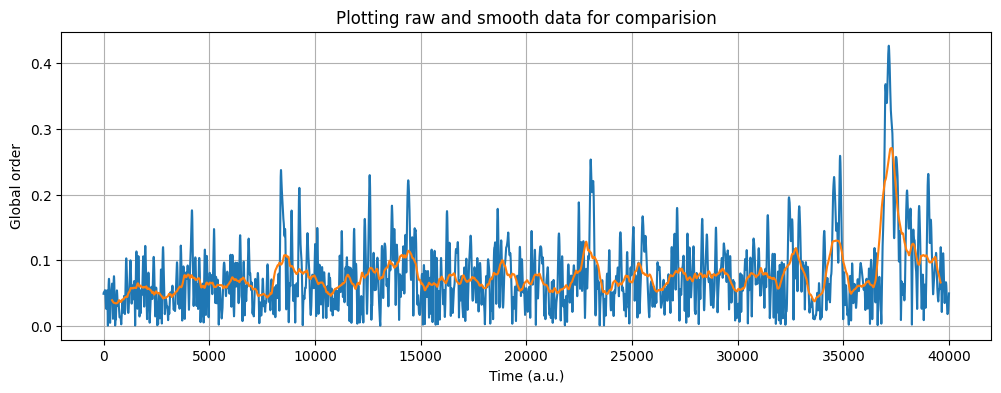

In [39]:
#To plot comparision, uncomment
f = plt.figure(figsize=(12, 4))
plt.title("Plotting raw and smooth data for comparision") 
n=11
sync_order = df[n]
sync_smooth = df_smooth[n]
plt.plot(time_steps,sync_order)
plt.plot(time_steps,sync_smooth)
plt.ylabel("Global order")
plt.xlabel("Time (a.u.)")
plt.grid(True)
plt.show()

In [40]:
df_na=df_smooth.dropna()

In [41]:
df_na.shape

(39201, 215)

In [47]:
df_na.head()

,0,1,2,3,4,5,6,7,8,9,...,205,206,207,208,209,210,211,212,213,214
400,0.038642,0.047825,0.042576,0.040375,0.049584,0.040951,0.040215,0.026198,0.052388,0.053102,...,0.051726,0.043580,0.032887,0.042889,0.051054,0.039953,0.046796,0.052810,0.043688,0.054868
401,0.038691,0.047849,0.042568,0.040422,0.049618,0.040941,0.040138,0.026210,0.052381,0.053070,...,0.051779,0.043660,0.032881,0.042882,0.051046,0.039936,0.046805,0.052812,0.043744,0.054878
402,0.038741,0.047875,0.042561,0.040469,0.049652,0.040929,0.040064,0.026222,0.052374,0.053037,...,0.051832,0.043744,0.032875,0.042875,0.051037,0.039919,0.046813,0.052811,0.043801,0.054890
403,0.038791,0.047904,0.042556,0.040517,0.049685,0.040916,0.039995,0.026232,0.052367,0.053003,...,0.051887,0.043833,0.032870,0.042867,0.051029,0.039903,0.046820,0.052809,0.043860,0.054902
404,0.038842,0.047934,0.042552,0.040565,0.049717,0.040902,0.039929,0.026242,0.052360,0.052968,...,0.051942,0.043925,0.032865,0.042858,0.051020,0.039888,0.046826,0.052805,0.043919,0.054916


In [48]:
#removing NaN entries
df_na=df_smooth.dropna()
time_steps_na = list(range(0,df_na.shape[0]))   #timesteps upto nepochs
time_na=np.multiply(time_steps_na,dt)

In [50]:
#taking only those iterations which have transition
trans_df = df_na[0]
for i in range(0,214):
    data = np.array(df_na[i])
    index_arr=np.where(data >= 0.45)[0]
    
    if index_arr.size > 0:
        
        trans_df=pd.concat([trans_df, df_na[i]], axis=1)
        

    else:
        #data_no_trans=pd.concat([data_no_trans, df_na[i]], axis=1)
        continue


In [51]:
trans_df.shape

(39201, 92)

In [ ]:
trans_time=[]
data_trans=df_na[0]        #initialising dataframe for storing only transition iterations
data_no_trans=df_na[0]     #initialising dataframe for storing only no transition iterations
for i in range(0,83):    

    
    data = np.array(df_na[i])
    indice=np.where(data >= 0.45)[0]
    
    if indice.size > 0:
        upper_crossing = indice[0]
        data_trans=pd.concat([data_trans, df_na[i]], axis=1)
        

    else:
        #data_no_trans=pd.concat([data_no_trans, df_na[i]], axis=1)
        continue
    
    l1 = np.where(data >= 0.1)[0]
    l2=np.where(data <= 0.101)[0]
    low_intersection = np.intersect1d(l1, l2)
    low_upd =low_intersection[low_intersection<upper_crossing]

    lower_crossing=low_upd[-1]
    
    t=(upper_crossing-lower_crossing)*0.05
    trans_time.append(t)
    

print(np.array(trans_time))

21.950000000000003
30701
9752
1047.45


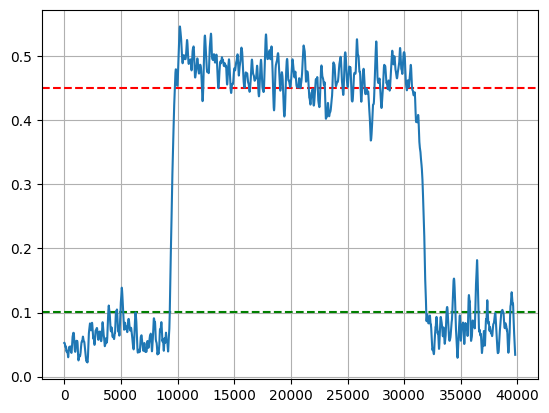

In [28]:
n=15#put n as what iteration you want to plot
data = np.array(df_na[n])
#Finding first upper crossing
upper_crossing = np.where(data >= 0.45)[0][0]
#Finding 2nd upper crossing
upper_crossing_2 = np.where(data >= 0.45)[0][-1]
#searching for lower level in vicinity of upper crossing only
low_data=np.array(data[upper_crossing-1000:upper_crossing])
#print(low_data)
#lower level index but not actual index for plotting
lower_crossing_dum=np.where(low_data >=0.1)[0][0]
#Adding correction in actual index
lower_crossing=lower_crossing_dum+(upper_crossing-1000)
#Calculating Transition time
t=(upper_crossing-lower_crossing)*0.05
print(t)
print(upper_crossing_2)
print(upper_crossing)
state_time = (upper_crossing_2-upper_crossing)*0.05
print(state_time)
fig, ax = plt.subplots()

# Plot 
ax.axhline(y=data[upper_crossing], color='r', linestyle='--', label='y = upper level')
ax.axhline(y=data[lower_crossing], color='g', linestyle='--', label='y = lower level')
plt.plot(time_steps_na,df_na[n])


plt.grid()